# Hypotesetest for to utvalg, andelstest og ANOVA — Python-beregninger

Denne notatboken inneholder alle Python-beregningene fra beamer-presentasjonen
**«Hypotesetest for to utvalg, andelstest og ANOVA»**, i samme rekkefølge som slidene:

1. Forutsetninger for hypotesetest (Q–Q-plott, skjevhet/kurtosis, Shapiro–Wilk, Levene)
2. To uavhengige utvalg (pooled $t$-test)
3. Welchs $t$-test (ulik varians)
4. Parede (avhengige) utvalg
5. Andelstest for to utvalg
6. Ensidig ANOVA + post-hoc (Tukey HSD)



In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(2026)
plt.rcParams["figure.figsize"] = (6, 4)
ORANGE = "#E8743B"
BLUE = "#1f4e8c"
GRAY = "#888888"


---
## 1. Forutsetninger for hypotesetest

### Eksempel: Q–Q-plott for aldersfordeling i en klasse

**Data:** Alder på $N=13$ studenter (og læreren) i en klasse.

In [2]:
age = np.array([21, 22, 23, 23, 24, 25, 26, 26, 30, 31, 32, 43, 44])
N = len(age)
mu, sigma = age.mean(), age.std(ddof=1)
print(f"N={N}, gjennomsnitt={mu:.2f}, standardavvik={sigma:.2f}")

N=13, gjennomsnitt=28.46, standardavvik=7.50


In [3]:
# Plotting positions (i-0.5)/N og teoretiske kvantiler
p = (np.arange(1, N+1) - 0.5) / N
theoretical = stats.norm.ppf(p, mu, sigma)
observed = np.sort(age)

tabell = pd.DataFrame({
    "Persentil (%)": (p*100).round(1),
    "Alder (observert)": observed,
    "Teoretisk verdi": theoretical.round(1)
})
print(tabell.to_string(index=False))

 Persentil (%)  Alder (observert)  Teoretisk verdi
           3.8                 21             15.2
          11.5                 22             19.5
          19.2                 23             21.9
          26.9                 23             23.8
          34.6                 24             25.5
          42.3                 25             27.0
          50.0                 26             28.5
          57.7                 26             29.9
          65.4                 30             31.4
          73.1                 31             33.1
          80.8                 32             35.0
          88.5                 43             37.5
          96.2                 44             41.7


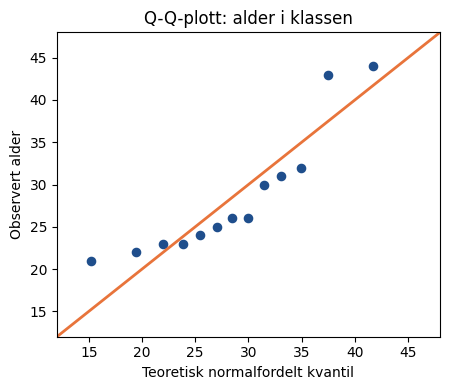

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
lims = [12, 48]
ax.plot(lims, lims, color=ORANGE, lw=2)
ax.scatter(theoretical, observed, color=BLUE, s=35)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Teoretisk normalfordelt kvantil")
ax.set_ylabel("Observert alder")
ax.set_title("Q-Q-plott: alder i klassen")
plt.tight_layout()
plt.show()

# Enklere: stats.probplot(age, dist="norm", plot=plt)

### Tolkning: skjevhet, kurtosis og Shapiro–Wilk

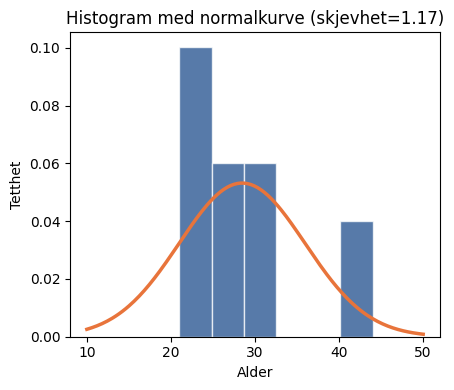

Skjevhet (skewness): 1.1749552101492264
Kurtosis: 0.1481049139969164
Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.8219617868008289), pvalue=np.float64(0.012580124968096832))


In [5]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.hist(age, bins=6, color=BLUE, alpha=0.75, edgecolor="white", density=True)
x = np.linspace(10, 50, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=ORANGE, lw=2.5)
ax.set_xlabel("Alder"); ax.set_ylabel("Tetthet")
ax.set_title(f"Histogram med normalkurve (skjevhet={stats.skew(age):.2f})")
plt.tight_layout()
plt.show()

print("Skjevhet (skewness):", stats.skew(age))
print("Kurtosis:", stats.kurtosis(age))
print("Shapiro-Wilk:", stats.shapiro(age))

**Tolkning:** Positiv skjevhet ($1.17$), og Shapiro–Wilk gir $p=0.013<0.05$
$\Rightarrow$ dataene er trolig ikke normalfordelte (lite overraskende med få, skjeve data).

### Levenes test for lik varians (generisk eksempel)

In [6]:
# Illustrasjon av syntaks (brukes senere med ekte grupper)
eksempel_g1 = np.array([1, 2, 3, 4, 5])
eksempel_g2 = np.array([2, 2, 3, 3, 4])
print(stats.levene(eksempel_g1, eksempel_g2))
print("p > 0.05 => ingen grunn til aa tro paa ulik varians.")

LeveneResult(statistic=np.float64(1.7999999999999998), pvalue=np.float64(0.21654728411266932))
p > 0.05 => ingen grunn til aa tro paa ulik varians.


---
## 2. Hypotesetest for to uavhengige utvalg

**Oppgave:** To grupper studenter ble undervist med hver sin metode før samme eksamen.
Er det en signifikant forskjell i eksamensresultat ($\alpha=0.05$)?

In [7]:
A = np.array([78, 82, 91, 85, 76, 88, 95, 80, 84, 90])
B = np.array([70, 75, 68, 82, 77, 74, 71, 79, 73, 80])

print(f"A: n={len(A)}, mean={A.mean():.2f}, sd={A.std(ddof=1):.2f}")
print(f"B: n={len(B)}, mean={B.mean():.2f}, sd={B.std(ddof=1):.2f}")

A: n=10, mean=84.90, sd=6.10
B: n=10, mean=74.90, sd=4.58


In [8]:
print("Shapiro A:", stats.shapiro(A))
print("Shapiro B:", stats.shapiro(B))
print("Levene:", stats.levene(A, B))

Shapiro A: ShapiroResult(statistic=np.float64(0.9779634664121185), pvalue=np.float64(0.9533438103427303))
Shapiro B: ShapiroResult(statistic=np.float64(0.9745041411399672), pvalue=np.float64(0.9291790359065917))
Levene: LeveneResult(statistic=np.float64(0.8640000000000003), pvalue=np.float64(0.36492052736748315))


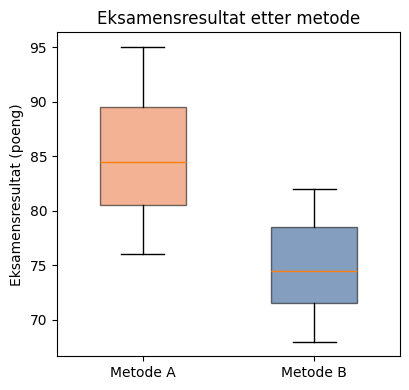

In [9]:
fig, ax = plt.subplots(figsize=(4.2, 4.0))
bp = ax.boxplot([A, B], tick_labels=["Metode A", "Metode B"], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [ORANGE, BLUE]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("Eksamensresultat (poeng)")
ax.set_title("Eksamensresultat etter metode")
plt.tight_layout()
plt.show()

Begge Shapiro-testene: $p>0.05$ (normalfordeling ok). Levene: $p=0.365>0.05$ (lik varians ok) $\Rightarrow$ pooled $t$-test.

In [10]:
T_obs, p_verdi = stats.ttest_ind(A, B, equal_var=True)
df_pooled = len(A) + len(B) - 2
print(f"T_obs = {T_obs:.4f}")
print(f"p = {p_verdi:.5f}")
print(f"df = {df_pooled}")

T_obs = 4.1451
p = 0.00061
df = 18


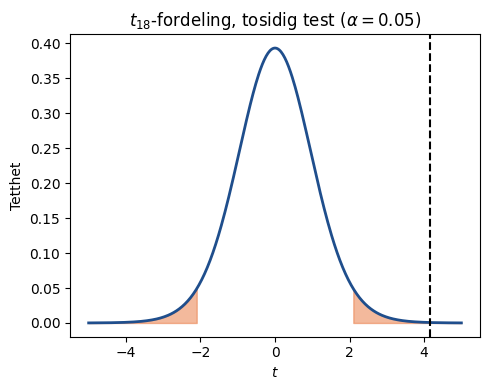

In [11]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
x = np.linspace(-5, 5, 400)
y = stats.t.pdf(x, df_pooled)
tcrit = stats.t.ppf(0.975, df_pooled)
ax.plot(x, y, color=BLUE, lw=2)
for xr in [np.linspace(-5, -tcrit, 100), np.linspace(tcrit, 5, 100)]:
    ax.fill_between(xr, stats.t.pdf(xr, df_pooled), color=ORANGE, alpha=0.5)
ax.axvline(T_obs, color="black", linestyle="--")
ax.set_xlabel("$t$"); ax.set_ylabel("Tetthet")
ax.set_title(f"$t_{{{df_pooled}}}$-fordeling, tosidig test ($\\alpha=0.05$)")
plt.tight_layout()
plt.show()

**Konklusjon:** $p=0.0006<0.05$ $\Rightarrow$ **forkast $H_0$**: signifikant forskjell mellom metodene.

---
## 3. Welchs $t$-test (ulik varians)

**Oppgave:** Kundetilfredshet ved to filialer: Filial A ($n=15$) og Filial B ($n=5$,
mer variabel drift). Er det forskjell i gjennomsnittlig tilfredshet ($\alpha=0.05$)?

In [12]:
filial_A = np.array([78, 82, 80, 79, 81, 80, 78, 82, 79, 81, 80, 79, 82, 80, 81])
filial_B = np.array([70, 95, 68, 98, 84])

print(f"A: n={len(filial_A)}, sd={filial_A.std(ddof=1):.2f}")
print(f"B: n={len(filial_B)}, sd={filial_B.std(ddof=1):.2f}")
print("Levene:", stats.levene(filial_A, filial_B))

A: n=15, sd=1.36
B: n=5, sd=13.82
Levene: LeveneResult(statistic=np.float64(38.513685427910566), pvalue=np.float64(7.412239324334822e-06))


Filial B har mye større spredning, og Levene forkaster klart lik varians $\Rightarrow$ bruk Welch.

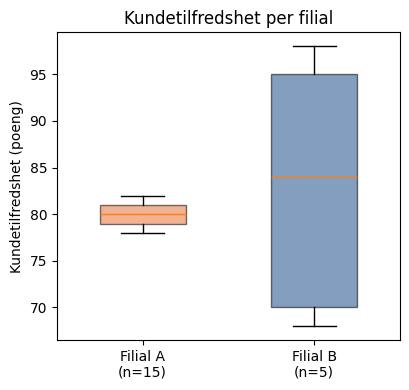

In [13]:
fig, ax = plt.subplots(figsize=(4.2, 4.0))
bp = ax.boxplot([filial_A, filial_B], tick_labels=["Filial A\n(n=15)", "Filial B\n(n=5)"],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [ORANGE, BLUE]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("Kundetilfredshet (poeng)")
ax.set_title("Kundetilfredshet per filial")
plt.tight_layout()
plt.show()

In [14]:
T_obs, p_welch = stats.ttest_ind(filial_A, filial_B, equal_var=False)
print(f"Welch:  T_obs={T_obs:.3f}, p={p_welch:.4f}")

T_check, p_pooled = stats.ttest_ind(filial_A, filial_B, equal_var=True)
print(f"Pooled (feil metode her): T_obs={T_check:.3f}, p={p_pooled:.4f}")

nA, nB = len(filial_A), len(filial_B)
vA, vB = filial_A.var(ddof=1), filial_B.var(ddof=1)
df_welch = (vA/nA + vB/nB)**2 / ((vA/nA)**2/(nA-1) + (vB/nB)**2/(nB-1))
df_pooled = nA + nB - 2
print(f"\ndf_Welch = {df_welch:.2f}  (vs. df_pooled = {df_pooled})")

Welch:  T_obs=-0.463, p=0.6672
Pooled (feil metode her): T_obs=-0.838, p=0.4130

df_Welch = 4.03  (vs. df_pooled = 18)


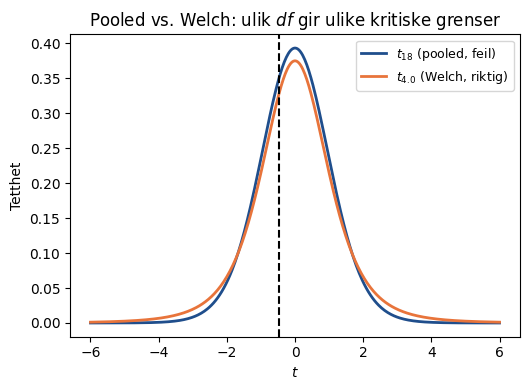

In [15]:
fig, ax = plt.subplots(figsize=(5.4, 4.0))
x = np.linspace(-6, 6, 400)
ax.plot(x, stats.t.pdf(x, df_pooled), color=BLUE, lw=2, label=f"$t_{{{df_pooled}}}$ (pooled, feil)")
ax.plot(x, stats.t.pdf(x, df_welch), color=ORANGE, lw=2, label=f"$t_{{{df_welch:.1f}}}$ (Welch, riktig)")
ax.axvline(T_obs, color="black", linestyle="--")
ax.set_xlabel("$t$"); ax.set_ylabel("Tetthet")
ax.set_title("Pooled vs. Welch: ulik $df$ gir ulike kritiske grenser")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Konklusjon:** Welch: $p=0.667>0.05$ $\Rightarrow$ **behold $H_0$**. Den (feilaktige) pooled-testen
hadde gitt $p=0.413$ --- fortsatt ikke signifikant her, men mye mer selvsikker enn den burde vært.

---
## 4. Parede (avhengige) utvalg

**Oppgave:** $10$ ansatte gjennomførte en konsentrasjonstest før og etter et kurs i
tidsstyring. Ga kurset en signifikant forbedring ($\alpha=0.05$)?

In [16]:
before = np.array([62, 58, 71, 65, 60, 55, 69, 63, 57, 66])
after  = np.array([71, 60, 77, 64, 68, 58, 74, 70, 58, 72])

d = after - before
print("Differanser d_i:", d)
print("Shapiro-Wilk paa differansene:", stats.shapiro(d))

Differanser d_i: [ 9  2  6 -1  8  3  5  7  1  6]
Shapiro-Wilk paa differansene: ShapiroResult(statistic=np.float64(0.960096652853073), pvalue=np.float64(0.7869740715945205))


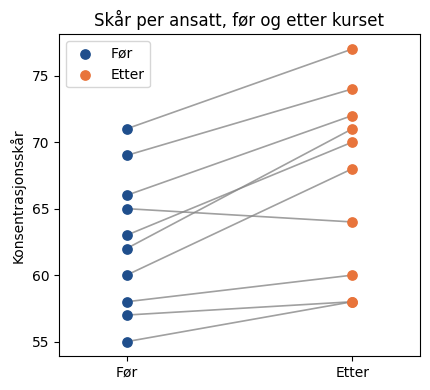

In [17]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
for b, a in zip(before, after):
    ax.plot([0, 1], [b, a], color=GRAY, lw=1.2, alpha=0.8)
ax.scatter(np.zeros_like(before), before, color=BLUE, s=45, label="Før", zorder=2)
ax.scatter(np.ones_like(after), after, color=ORANGE, s=45, label="Etter", zorder=2)
ax.set_xlim(-0.3, 1.3); ax.set_xticks([0, 1]); ax.set_xticklabels(["Før", "Etter"])
ax.set_ylabel("Konsentrasjonsskår")
ax.set_title("Skår per ansatt, før og etter kurset")
ax.legend()
plt.tight_layout()
plt.show()

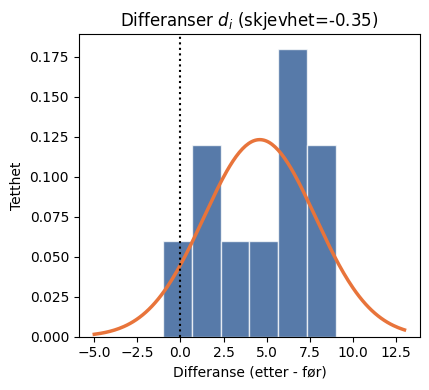

In [18]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
ax.hist(d, bins=6, color=BLUE, alpha=0.75, edgecolor="white", density=True)
x = np.linspace(d.min()-4, d.max()+4, 200)
ax.plot(x, stats.norm.pdf(x, d.mean(), d.std(ddof=1)), color=ORANGE, lw=2.5)
ax.axvline(0, color="black", linestyle=":")
ax.set_xlabel("Differanse (etter - før)"); ax.set_ylabel("Tetthet")
ax.set_title(f"Differanser $d_i$ (skjevhet={stats.skew(d):.2f})")
plt.tight_layout()
plt.show()

In [19]:
dbar = d.mean()
sd = d.std(ddof=1)
se = sd / np.sqrt(len(d))
T_obs = dbar / se
df = len(d) - 1
p_verdi = stats.t.sf(T_obs, df)

print(f"dbar={dbar:.2f}, sd={sd:.3f}, se={se:.3f}, df={df}")
print(f"T_obs={T_obs:.4f}, p={p_verdi:.5f}")

# eller direkte:
print(stats.ttest_rel(after, before, alternative="greater"))

ki = (dbar - stats.t.ppf(0.975, df)*se, dbar + stats.t.ppf(0.975, df)*se)
print(f"95% KI for mu_d: [{ki[0]:.2f}, {ki[1]:.2f}]")

dbar=4.60, sd=3.239, se=1.024, df=9
T_obs=4.4915, p=0.00075
TtestResult(statistic=np.float64(4.4915174288384225), pvalue=np.float64(0.0007536120326256195), df=np.int64(9))
95% KI for mu_d: [2.28, 6.92]


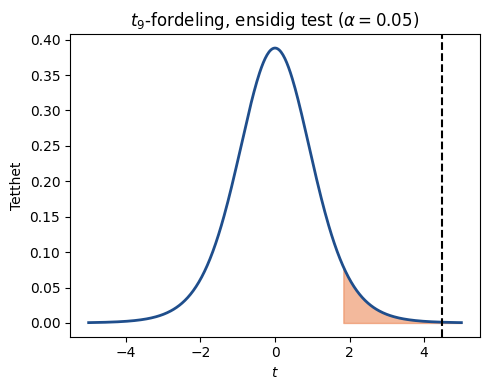

In [20]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
x = np.linspace(-5, 5, 400)
tcrit = stats.t.ppf(0.95, df)
ax.plot(x, stats.t.pdf(x, df), color=BLUE, lw=2)
xr = np.linspace(tcrit, 5, 100)
ax.fill_between(xr, stats.t.pdf(xr, df), color=ORANGE, alpha=0.5)
ax.axvline(T_obs, color="black", linestyle="--")
ax.set_xlabel("$t$"); ax.set_ylabel("Tetthet")
ax.set_title(f"$t_{{{df}}}$-fordeling, ensidig test ($\\alpha=0.05$)")
plt.tight_layout()
plt.show()

**Konklusjon:** $p=0.00075<0.05$ $\Rightarrow$ **forkast $H_0$**: kurset ga en signifikant
forbedring. $95\,\%$ KI for $\mu_d$: $[2.28,\ 6.92]$.

---
## 5. Andelstest for to utvalg

**Oppgave:** To ulike reklamekampanjer ble testet. Kampanje A ga $62$ konverteringer
av $200$, kampanje B ga $32$ av $180$. Er kampanje A signifikant bedre enn B ($\alpha=0.05$)?

In [21]:
n1, x1 = 200, 62
n2, x2 = 180, 32

p1, p2 = x1/n1, x2/n2
p_pool = (x1 + x2) / (n1 + n2)

SE = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
Z_obs = (p1 - p2) / SE
p_verdi = stats.norm.sf(Z_obs)

print(f"p1={p1:.4f}, p2={p2:.4f}, p_pool={p_pool:.4f}")
print(f"Z_obs={Z_obs:.4f}, p={p_verdi:.5f}")

p1=0.3100, p2=0.1778, p_pool=0.2474
Z_obs=2.9826, p=0.00143


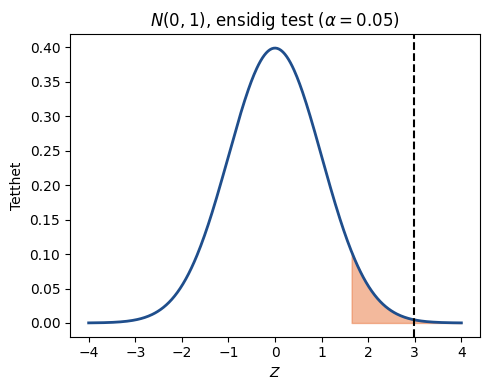

In [22]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
x = np.linspace(-4, 4, 400)
zcrit = stats.norm.ppf(0.95)
ax.plot(x, stats.norm.pdf(x), color=BLUE, lw=2)
xr = np.linspace(zcrit, 4, 100)
ax.fill_between(xr, stats.norm.pdf(xr), color=ORANGE, alpha=0.5)
ax.axvline(Z_obs, color="black", linestyle="--")
ax.set_xlabel("$Z$"); ax.set_ylabel("Tetthet")
ax.set_title("$N(0,1)$, ensidig test ($\\alpha=0.05$)")
plt.tight_layout()
plt.show()

In [23]:
# 95% KI for differansen (bruker separate andeler i SE, ikke pooled)
SE_ci = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
z = stats.norm.ppf(0.975)
ki = (p1 - p2 - z*SE_ci, p1 - p2 + z*SE_ci)
print(f"95% KI for p1-p2: [{ki[0]:.3f}, {ki[1]:.3f}]")

95% KI for p1-p2: [0.047, 0.217]


**Konklusjon:** $p=0.0014<0.05$ $\Rightarrow$ **forkast $H_0$**: kampanje A har
signifikant høyere konverteringsrate. $95\,\%$ KI for $p_A-p_B$: $[0.047,\,0.217]$ ---
dekker ikke $0$, samme konklusjon.

---
## 6. Ensidig ANOVA

**Oppgave:** Tre typer gjødsel testes på $6$ planter hver. Er det forskjell i
gjennomsnittlig plantehøyde mellom gjødseltypene ($\alpha=0.05$)?

In [24]:
gA = np.array([23, 25, 21, 24, 22, 26])
gB = np.array([28, 30, 27, 31, 29, 26])
gC = np.array([20, 22, 19, 23, 21, 18])

for navn, g in zip(["A", "B", "C"], [gA, gB, gC]):
    print(f"{navn}: mean={g.mean():.2f}, sd={g.std(ddof=1):.2f}, "
          f"Shapiro p={stats.shapiro(g).pvalue:.3f}")

print("\nLevene:", stats.levene(gA, gB, gC))

A: mean=23.50, sd=1.87, Shapiro p=0.961
B: mean=28.50, sd=1.87, Shapiro p=0.961
C: mean=20.50, sd=1.87, Shapiro p=0.961

Levene: LeveneResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))


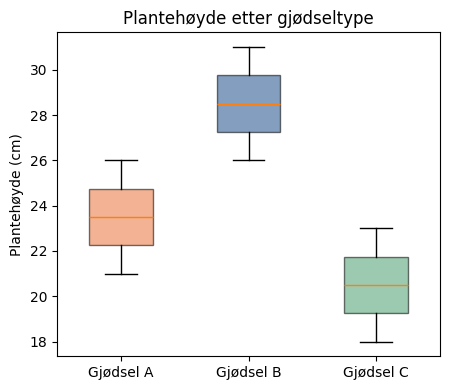

In [25]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
bp = ax.boxplot([gA, gB, gC], tick_labels=["Gjødsel A", "Gjødsel B", "Gjødsel C"],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [ORANGE, BLUE, "#4C9F70"]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("Plantehøyde (cm)")
ax.set_title("Plantehøyde etter gjødseltype")
plt.tight_layout()
plt.show()

Alle $p$-verdier $>0.05$: verken normalitets- eller variansantakelsen er i tvil her.

In [26]:
df_data = pd.DataFrame({
    "verdi": np.concatenate([gA, gB, gC]),
    "gruppe": ["A"]*6 + ["B"]*6 + ["C"]*6
})

model = ols("verdi ~ gruppe", data=df_data).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

SSG = anova_table["sum_sq"].iloc[0]
SSE = anova_table["sum_sq"].iloc[1]
eta2 = SSG / (SSG + SSE)
print(f"\neta^2 = {eta2:.3f}")

            df  sum_sq  mean_sq     F    PR(>F)
gruppe     2.0   196.0     98.0  28.0  0.000009
Residual  15.0    52.5      3.5   NaN       NaN

eta^2 = 0.789


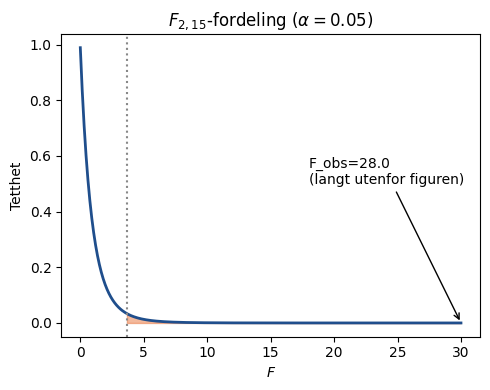

F_obs = 28.00, F_krit(0.05) = 3.68


In [27]:
dfG, dfE = 2, 15
F_obs = anova_table["F"].iloc[0]
Fcrit = stats.f.ppf(0.95, dfG, dfE)

fig, ax = plt.subplots(figsize=(5.0, 4.0))
x = np.linspace(0.01, 30, 400)
ax.plot(x, stats.f.pdf(x, dfG, dfE), color=BLUE, lw=2)
xr = np.linspace(Fcrit, 30, 100)
ax.fill_between(xr, stats.f.pdf(xr, dfG, dfE), color=ORANGE, alpha=0.5)
ax.axvline(Fcrit, color=GRAY, linestyle=":")
ax.annotate(f"F_obs={F_obs:.1f}\n(langt utenfor figuren)", xy=(30, 0), xytext=(18, 0.5),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("$F$"); ax.set_ylabel("Tetthet")
ax.set_title(f"$F_{{{dfG},{dfE}}}$-fordeling ($\\alpha=0.05$)")
plt.tight_layout()
plt.show()

print(f"F_obs = {F_obs:.2f}, F_krit(0.05) = {Fcrit:.2f}")

**Konklusjon:** $F(2,15)=28.0$, $p\approx8.6\times10^{-6}<0.05$ $\Rightarrow$
**forkast $H_0$**: gjødseltype påvirker plantehøyden. $\eta^2\approx0.79$ (stor effekt).

### Post-hoc-test: Tukeys HSD

In [28]:
post = pairwise_tukeyhsd(df_data["verdi"], df_data["gruppe"])
print(post)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B      5.0 0.0009   2.1944  7.8056   True
     A      C     -3.0 0.0355  -5.8056 -0.1944   True
     B      C     -8.0    0.0 -10.8056 -5.1944   True
-----------------------------------------------------


**Tolkning:** Alle tre gjødseltypene skiller seg signifikant fra hverandre ---
gjødsel B gir høyest plantehøyde, gjødsel C lavest.